GPU: True
CUDA reset successful
Creating model with GPU mode: True
Starting training...


100%|█████████████████████████████████| 3000/3000 [00:40<00:00, 74.46it/s, Iter=3000, Loss=8.54e-03]


Adam done!
Iter: 3001 Loss: 0.008581165224313736
Iter: 3002 Loss: 0.008574355393648148
Iter: 3003 Loss: 0.00857417844235897
Iter: 3004 Loss: 0.008573964238166809
Iter: 3005 Loss: 0.008573769591748714
Iter: 3006 Loss: 0.008573561906814575
Iter: 3007 Loss: 0.00857336912304163
Iter: 3008 Loss: 0.008573164232075214
Iter: 3009 Loss: 0.00857296772301197
Iter: 3010 Loss: 0.008572767488658428
Iter: 3011 Loss: 0.008572562597692013
Iter: 3012 Loss: 0.00857236422598362
Iter: 3013 Loss: 0.0085721705108881
Iter: 3014 Loss: 0.008571973070502281
Iter: 3015 Loss: 0.00857176911085844
Iter: 3016 Loss: 0.008571574464440346
Iter: 3017 Loss: 0.008571373298764229
Iter: 3018 Loss: 0.008571174927055836
Iter: 3019 Loss: 0.008570976555347443
Iter: 3020 Loss: 0.008570780046284199
Iter: 3021 Loss: 0.00857058260589838
Iter: 3022 Loss: 0.008570382371544838
Iter: 3023 Loss: 0.008570190519094467
Iter: 3024 Loss: 0.008569993078708649
Iter: 3025 Loss: 0.008569792844355106
Iter: 3026 Loss: 0.008569595403969288
Iter: 302

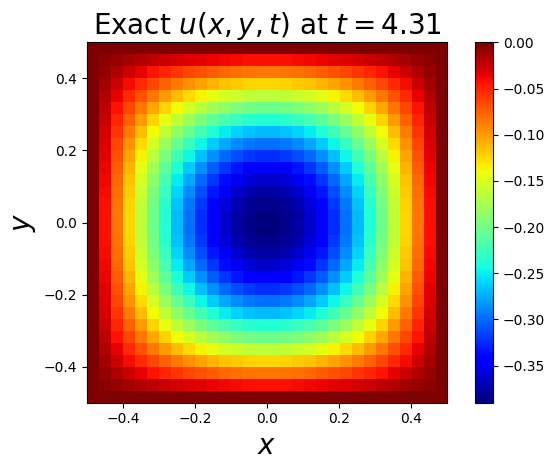

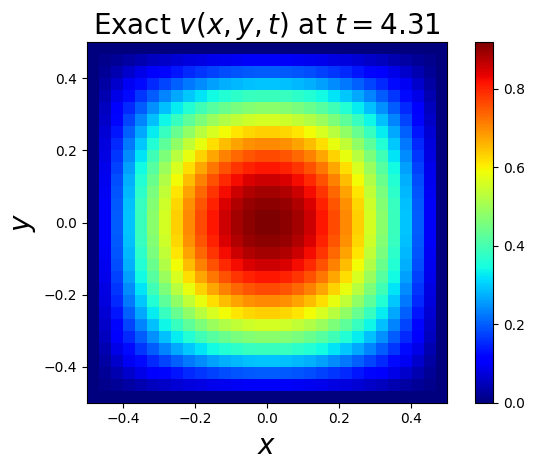

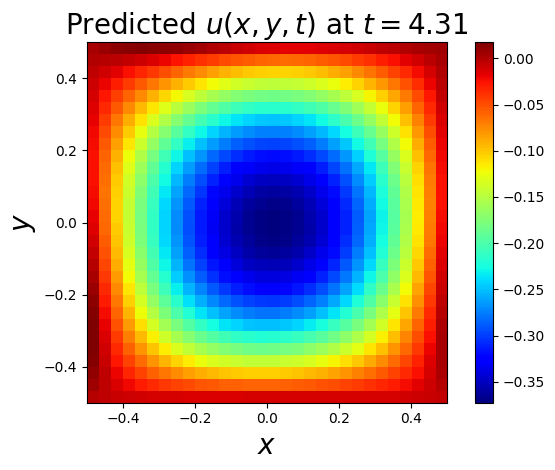

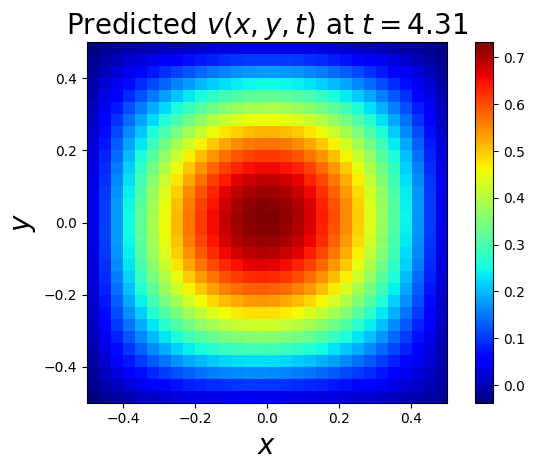

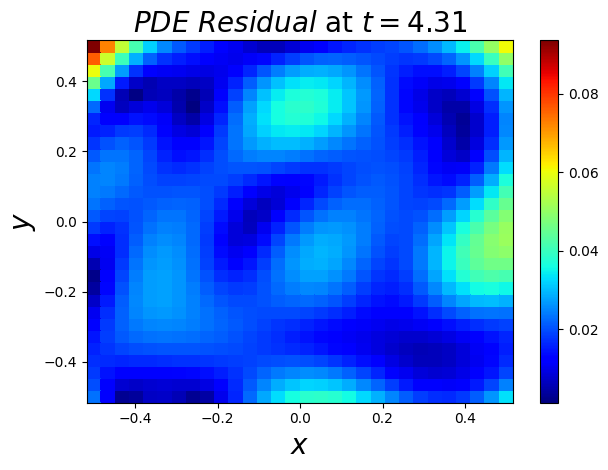

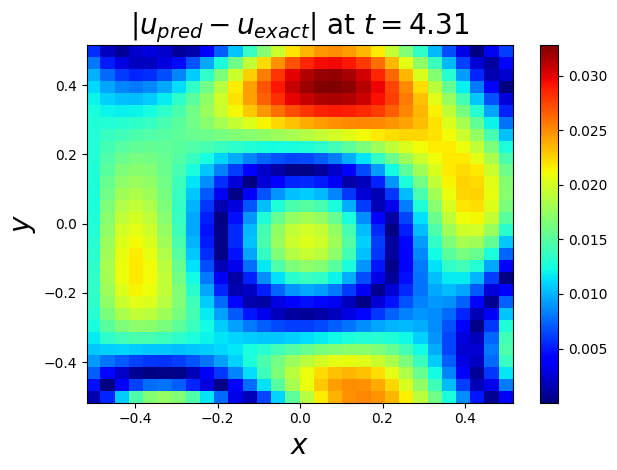

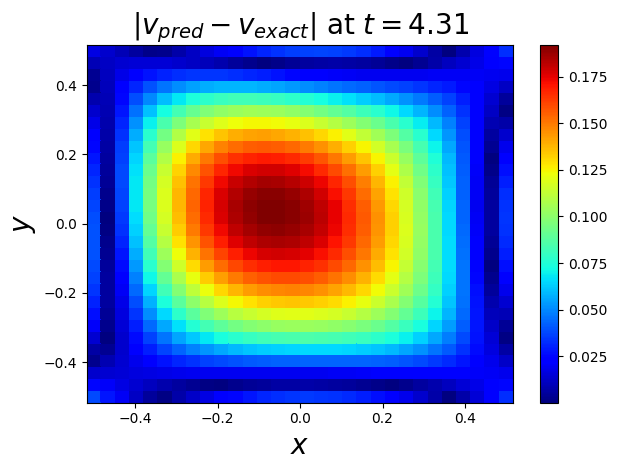

In [3]:
import os
import time
import numpy as np
import torch
from matplotlib import pyplot as plt, gridspec
from torch import nn
from torch.autograd import Variable
from tqdm import tqdm, trange
from pyDOE import lhs

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
seed = 1234
torch.set_default_dtype(torch.float)

# 安全的CUDA初始化
use_gpu = torch.cuda.is_available()
print('GPU:', use_gpu)

# 设置随机种子
np.random.seed(seed)
torch.manual_seed(seed)
if use_gpu:
    try:
        torch.cuda.manual_seed_all(seed)
        # 清理CUDA缓存
        torch.cuda.empty_cache()
    except RuntimeError as e:
        print(f"CUDA error during initialization: {e}")
        print("Falling back to CPU mode")
        use_gpu = False


def reset_cuda():
    """重置CUDA状态"""
    global use_gpu
    if torch.cuda.is_available():
        try:
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            use_gpu = True
            print("CUDA reset successful")
            return True
        except RuntimeError as e:
            print(f"CUDA reset failed: {e}")
            use_gpu = False
            return False
    else:
        use_gpu = False
        return False


def random_fun(num):
    temp = torch.from_numpy(lb + (ub - lb) * lhs(3, num)).float()
    return is_cuda(temp)


def is_cuda(data):
    global use_gpu
    if use_gpu:
        try:
            return data.cuda()
        except RuntimeError as e:
            print(f"CUDA error, switching to CPU: {e}")
            use_gpu = False
            return data
    return data


class FCNet(nn.Module):
    """FC Neural Network."""
    def __init__(self, layers, w_init=True, active=nn.Tanh()):
        super(FCNet, self).__init__()

        # Parameters
        self.depth = len(layers) - 1
        self.active = active

        # Layers list
        layer_list = list()
        for layer in range(self.depth - 1):
            layer_list.append(
                nn.Linear(layers[layer], layers[layer+1])
            )
            layer_list.append(active)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        # Net
        self.main = nn.Sequential(*layer_list)

        # Initialize parameters
        if w_init:
            self.initialize_weights()

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1)
                m.bias.data.zero_()

    def forward(self, x):
        return self.main(x)


class Net(nn.Module):
    """Deep Residual Learning for Image Recognition[arXiv:1512.03385]."""
    def __init__(self, backbone_layers, residual_layers):
        super(Net, self).__init__()

        # Check input and output
        if len(residual_layers) > 0 and backbone_layers[-2] != residual_layers[-1]:
            raise AssertionError("Output size of backbone net and residual net do not match!")
        self.iter = 0
        # layers
        self.res_layers = residual_layers
        self.backbone_layers = backbone_layers

        # Input layer
        self.input_layer = FCNet(self.backbone_layers[:2])

        # Backbone network.
        self.backbone = FCNet(self.backbone_layers[1:-1])

        # Residual network.
        self.residual = self._build_resnet()

        # Output layer
        self.output = FCNet(self.backbone_layers[-2:])

    def _build_resnet(self):
        """Build Res Connection."""
        if len(self.res_layers) == 0:
            return None
        layer_list = list()
        layer_list.append(nn.Linear(self.backbone_layers[1], self.res_layers[0]))
        layer_list.append(nn.Tanh())

        if len(self.res_layers) <= 1:
            return nn.Sequential(*layer_list)

        for layer in range(1, len(self.res_layers)-1):
            layer_list.append(nn.Linear(self.res_layers[layer], self.res_layers[layer+1]))
            layer_list.append(nn.Tanh())

        return nn.Sequential(*layer_list)

    def forward(self, x):
        x = self.input_layer(x)
        b = self.backbone(x)

        if self.residual is not None:
            r = self.residual(x)
            x = r + b
        x = x + b

        return self.output(x)


class Model:
    def __init__(self, net, x_bc,
                 u_bc,
                 x_ic,
                 u_ic, x_f_loss_fun,
                 x_test, x_test_exact
                 ):

        self.x_ic_s = None
        self.x_bc_s = None
        self.x_ict_s = None
        self.x_f_s = None
        self.s_collect = []

        self.optimizer_LBGFS = None
        self.net = net

        self.x_bc = x_bc
        self.u_bc = u_bc

        self.x_ic = x_ic
        self.u_ic = u_ic

        self.x_f_N = None
        self.x_f_M = None

        self.x_f_loss_fun = x_f_loss_fun

        self.x_test = x_test
        self.x_test_exact = x_test_exact

        self.start_loss_collect = False
        self.x_label_loss_collect = []
        self.x_f_loss_collect = []
        self.x_test_estimate_collect = []

    def train_U(self, x):
        return self.net(x)

    def predict_U(self, x):
        return self.train_U(x)

    def likelihood_loss(self, loss_e, loss_ic, loss_bc, loss_u0t):
        loss = torch.exp(-self.x_f_s) * loss_e.detach() + self.x_f_s \
               + torch.exp(-self.x_ic_s) * loss_ic.detach() + self.x_ic_s \
               + torch.exp(-self.x_bc_s) * loss_bc.detach() + self.x_bc_s \
               + torch.exp(-self.x_ict_s) * loss_u0t.detach() + self.x_ict_s
        return loss

    def true_loss(self, loss_e, loss_ic, loss_bc, loss_u0t):
        return torch.exp(-self.x_f_s.detach()) * loss_e + torch.exp(-self.x_ic_s.detach()) * loss_ic + torch.exp(
            -self.x_bc_s.detach()) * loss_bc + torch.exp(
            -self.x_ict_s.detach()) * loss_u0t

    # compute backward loss
    def epoch_loss(self):
        x_f = torch.cat((self.x_f_N, self.x_f_M), dim=0)
        loss_equation_u, loss_equation_v = self.x_f_loss_fun(x_f, self.train_U)
        loss_equation = torch.mean(loss_equation_u ** 2) + torch.mean(loss_equation_v ** 2)

        loss_ic = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)

        loss_bc = torch.mean((self.train_U(self.x_bc) - self.u_bc) ** 2)

        x = Variable(self.x_ic, requires_grad=True)
        u0 = self.train_U(x)
        u0_t = torch.autograd.grad(u0, x, grad_outputs=torch.ones_like(u0), create_graph=True)[0][:, [0]]
        loss_u0t = torch.mean(u0_t ** 2)

        return loss_equation, loss_ic, loss_bc, loss_u0t

    # compute backward loss
    def LBGFS_epoch_loss(self):
        self.optimizer_LBGFS.zero_grad()
        x_f = torch.cat((self.x_f_N, self.x_f_M), dim=0)
        loss_equation_u, loss_equation_v = self.x_f_loss_fun(x_f, self.train_U)
        loss_equation = torch.mean(loss_equation_u ** 2) + torch.mean(loss_equation_v ** 2)

        loss_ic = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)

        loss_bc = torch.mean((self.train_U(self.x_bc) - self.u_bc) ** 2)

        x = Variable(self.x_ic, requires_grad=True)
        u0 = self.train_U(x)
        u0_t = torch.autograd.grad(u0, x, grad_outputs=torch.ones_like(u0), create_graph=True)[0][:, [0]]
        loss_u0t = torch.mean(u0_t ** 2)

        loss = self.true_loss(loss_equation, loss_ic, loss_bc, loss_u0t)
        loss.backward()
        self.net.iter += 1
        print('Iter:', self.net.iter, 'Loss:', loss.item())
        return loss

    def evaluate(self):
        pred = self.train_U(self.x_test).cpu().detach().numpy()
        exact = self.x_test_exact.cpu().detach().numpy()
        error = np.linalg.norm(pred - exact, 2) / np.linalg.norm(exact, 2)
        return error

    def run_baseline(self):
        optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
        self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr,
                                                 max_iter=lbgfs_iter)
        pbar = trange(adam_iter, ncols=100)
        for i in pbar:
            optimizer_adam.zero_grad()
            loss_e, loss_ic, loss_bc, loss_u0t = self.epoch_loss()
            loss = self.true_loss(loss_e, loss_ic, loss_bc, loss_u0t)
            loss.backward()
            optimizer_adam.step()
            self.net.iter += 1
            pbar.set_postfix({'Iter': self.net.iter,
                              'Loss': '{0:.2e}'.format(loss.item())
                              })

        print('Adam done!')
        self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
        print('LBGFS done!')

        error = self.evaluate()
        print('Test_L2error:', '{0:.2e}'.format(error))

    def run_AM(self):
        for move_count in range(AM_count):
            self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr,
                                                     max_iter=lbgfs_iter)
            optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
            pbar = trange(adam_iter, ncols=100)

            for i in pbar:
                optimizer_adam.zero_grad()
                loss_e, loss_ic, loss_bc, loss_u0t = self.epoch_loss()
                loss = self.true_loss(loss_e, loss_ic, loss_bc, loss_u0t)
                loss.backward()
                self.net.iter += 1
                optimizer_adam.step()
                pbar.set_postfix({'Iter': self.net.iter,
                                  'Loss': '{0:.2e}'.format(loss.item())
                                  })

            print('Adam done!')
            self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
            print('LBGFS done!')

            error = self.evaluate()
            print('change_counts', move_count, 'Test_L2error:', '{0:.2e}'.format(error))
            self.x_test_estimate_collect.append([move_count, '{0:.2e}'.format(error)])

            if AM_type == 0:
                x_init = random_fun(100000)
                loss_eq_u, loss_eq_v = self.x_f_loss_fun(x_init, self.train_U)
                x_init_residual = abs(loss_eq_u) + abs(loss_eq_v)
                x_init_residual = x_init_residual.cpu().detach().numpy()
                err_eq = np.power(x_init_residual, AM_K) / np.power(x_init_residual, AM_K).mean()
                err_eq_normalized = (err_eq / sum(err_eq))[:, 0]
                X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=err_eq_normalized)
                self.x_f_M = x_init[X_ids]

            elif AM_type == 1:
                x_init = random_fun(100000)
                x = Variable(x_init, requires_grad=True)
                u = self.train_U(x)
                dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
                grad_norm = torch.norm(dx, dim=1).cpu().detach().numpy()
                err_dx = np.power(grad_norm, AM_K) / np.power(grad_norm, AM_K).mean()
                p = (err_dx / sum(err_dx))
                X_ids = np.random.choice(a=len(x_init), size=M, replace=False, p=p)
                self.x_f_M = x_init[X_ids]

    def train(self):
        try:
            self.x_f_N = random_fun(N)
            self.x_f_M = random_fun(M)

            self.x_f_s = is_cuda(torch.tensor(0.).float())
            self.x_ic_s = is_cuda(torch.tensor(0.).float())
            self.x_bc_s = is_cuda(torch.tensor(0.).float())
            self.x_ict_s = is_cuda(torch.tensor(0.).float())

            start_time = time.time()
            if model_type == 0:
                self.run_baseline()
            elif model_type == 1:
                self.run_AM()
            elapsed = time.time() - start_time

            print('Training time: %.2f' % elapsed)
            
        except RuntimeError as e:
            print(f"Training error: {e}")
            if "CUDA" in str(e):
                print("CUDA error detected, please restart kernel and try again")
            raise


def x_f_loss_fun(x, train_U):
    """
    2D NLSGE PDE loss function
    """
    if not x.requires_grad:
        x = Variable(x, requires_grad=True)
    
    uv = train_U(x)
    u = uv[:, [0]]  # u(x,y,t)
    v = uv[:, [1]]  # v(x,y,t)

    # First order derivatives for u
    u_grads = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)
    u_txy = u_grads[0]
    u_t = u_txy[:, [0]]
    u_x = u_txy[:, [1]]
    u_y = u_txy[:, [2]]

    # First order derivatives for v
    v_grads = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)
    v_txy = v_grads[0]
    v_t = v_txy[:, [0]]
    v_x = v_txy[:, [1]]
    v_y = v_txy[:, [2]]

    # Second order derivatives for u
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, [1]]
    u_yy = torch.autograd.grad(u_y, x, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, [2]]

    # Extract coordinates
    t = x[:, [0]]
    x_coord = x[:, [1]]
    y_coord = x[:, [2]]

    # Source terms
    source_term = torch.sin(torch.cos(np.pi * x_coord) * torch.cos(np.pi * y_coord) * torch.cos(t))

    # 2D NLSGE equations
    # du/dt = v(x,y,t)  (Equation 5.2a)
    f_u = u_t - v
    
    # dv/dt = (1/2π²)(∂²u/∂x² + ∂²u/∂y²) - sin(u) + sin(cos(πx)cos(πy)cos(t))  (Equation 5.2b)
    f_v = v_t - (1.0 / (2 * np.pi**2)) * (u_xx + u_yy) + torch.sin(u) - source_term

    return f_u, f_v


def exact_u(x):
    """
    Analytical solution for u: u(x,y,t) = cos(πx)cos(πy)cos(t)
    """
    t = x[:, 0]
    x_coord = x[:, 1]
    y_coord = x[:, 2]
    
    u = np.cos(np.pi * x_coord) * np.cos(np.pi * y_coord) * np.cos(t)
    return u[:, None]


def exact_v(x):
    """
    Analytical solution for v: v(x,y,t) = -cos(πx)cos(πy)sin(t)
    """
    t = x[:, 0]
    x_coord = x[:, 1]
    y_coord = x[:, 2]
    
    v = -np.cos(np.pi * x_coord) * np.cos(np.pi * y_coord) * np.sin(t)
    return v[:, None]


def exact_uv(x):
    u = exact_u(x)
    v = exact_v(x)
    return np.hstack((u, v))


def draw_exact():
    predict_np = model.predict_U(x_test).cpu().detach().numpy()
    u_test_np = x_test_exact.cpu().detach().numpy()
    e_u = np.reshape(u_test_np[:, 0], (len(t), len(x), len(y)))
    e_v = np.reshape(u_test_np[:, 1], (len(t), len(x), len(y)))

    pred_u = np.reshape(predict_np[:, 0], (len(t), len(x), len(y)))
    pred_v = np.reshape(predict_np[:, 1], (len(t), len(x), len(y)))

    time_idx = 25  # t=2.5
    plt.figure()
    plt.imshow(e_u[time_idx, :, :], extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title(r'Exact $u(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('NLSGE_u_exact.jpg')
    plt.show()

    plt.figure()
    plt.imshow(e_v[time_idx, :, :], extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title(r'Exact $v(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('NLSGE_v_exact.jpg')
    plt.show()

    # Predicted solutions
    plt.figure()
    plt.imshow(pred_u[time_idx, :, :], extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title(r'Predicted $u(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('NLSGE_u_pred.jpg')
    plt.show()

    plt.figure()
    plt.imshow(pred_v[time_idx, :, :], extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title(r'Predicted $v(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('NLSGE_v_pred.jpg')
    plt.show()


def draw_residual():
    f_u, f_v = x_f_loss_fun(x_test, model.train_U)
    f_u = f_u.cpu().detach().numpy()
    f_v = f_v.cpu().detach().numpy()
    
    residual = np.sqrt(f_u**2 + f_v**2)
    
    residual = np.reshape(residual, (len(t), len(x), len(y)))

    time_idx = 25 
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    plt.figure()
    plt.pcolor(X, Y, residual[time_idx, :, :], cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title('$PDE$ $Residual$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('NLSGE_residual.jpg')
    plt.show()


def draw_error():
    predict_np = model.predict_U(x_test).cpu().detach().numpy()
    u_test_np = x_test_exact.cpu().detach().numpy()
    
    error_u = np.abs(predict_np[:, 0] - u_test_np[:, 0])
    error_v = np.abs(predict_np[:, 1] - u_test_np[:, 1])
    
    error_u = np.reshape(error_u, (len(t), len(x), len(y)))
    error_v = np.reshape(error_v, (len(t), len(x), len(y)))
    
    time_idx = 25
    X, Y = np.meshgrid(x, y, indexing='ij')

    plt.figure()
    plt.pcolor(X, Y, error_u[time_idx, :, :], cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title('$|u_{pred} - u_{exact}|$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('NLSGE_u_error.jpg')
    plt.show()
    
    plt.figure()
    plt.pcolor(X, Y, error_v[time_idx, :, :], cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title('$|v_{pred} - v_{exact}|$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('NLSGE_v_error.jpg')
    plt.show()


if __name__ == '__main__':
    # 尝试重置CUDA
    reset_cuda()
    
    # Domain: Ω = [-0.5, 0.5] × [-0.5, 0.5], t ∈ [0, 5]
    lb = np.array([0.0, -0.5, -0.5])
    ub = np.array([5.0, 0.5, 0.5])

    # Network architecture
    net = is_cuda(Net([3, 50, 50, 50, 50, 2], [50, 50]))

    # Training parameters
    N = 1500  # Number of collocation points (fixed)
    M = 500   # Number of adaptive points
    Nbc = 50  # Number of boundary condition points
    Nic = 50  # Number of initial condition points

    adam_iter, lbgfs_iter = 3000, 5000
    adam_lr, lbgfs_lr = 0.001, 0.001

    model_type = 0  # 0:baseline  1:AM  2:AM_AW

    AM_type = 0  # 0:RAM  1:WAM
    AM_K = 2
    AM_count = 3

    # Create coordinate grids - 更小的网格避免内存问题
    t = np.linspace(0, 5, 30)
    x = np.linspace(-0.5, 0.5, 30)
    y = np.linspace(-0.5, 0.5, 30)
    T, X, Y = np.meshgrid(t, x, y, indexing='ij')

    # Test points
    x_test_np = np.hstack((T.flatten()[:, None], X.flatten()[:, None], Y.flatten()[:, None]))
    solution = exact_uv(x_test_np)
    x_test = is_cuda(torch.from_numpy(x_test_np).float())
    x_test_exact = is_cuda(torch.from_numpy(solution).float())

    # Initial conditions: u(x,y,0) and v(x,y,0)
    x_ic_np = np.hstack((np.zeros((Nic*Nic, 1)), 
                        np.random.uniform(-0.5, 0.5, (Nic*Nic, 1)), 
                        np.random.uniform(-0.5, 0.5, (Nic*Nic, 1))))
    u_ic_np = exact_uv(x_ic_np)

    x_ic = is_cuda(torch.from_numpy(x_ic_np).float())
    u_ic = is_cuda(torch.from_numpy(u_ic_np).float())

    # Boundary conditions: all boundaries are 0
    t_bc = np.random.uniform(0, 5, (Nbc*Nbc, 1))
    
    # Left boundary: x = -0.5
    x_bc = -0.5 * np.ones((Nbc*Nbc, 1))
    y_bc = np.random.uniform(-0.5, 0.5, (Nbc*Nbc, 1))
    x_bc_left = np.hstack((t_bc, x_bc, y_bc))
    u_bc_left = np.zeros((Nbc*Nbc, 2))  # u=0, v=0

    # Right boundary: x = 0.5
    x_bc = 0.5 * np.ones((Nbc*Nbc, 1))
    x_bc_right = np.hstack((t_bc, x_bc, y_bc))
    u_bc_right = np.zeros((Nbc*Nbc, 2))

    # Bottom boundary: y = -0.5
    x_bc = np.random.uniform(-0.5, 0.5, (Nbc*Nbc, 1))
    y_bc = -0.5 * np.ones((Nbc*Nbc, 1))
    x_bc_bottom = np.hstack((t_bc, x_bc, y_bc))
    u_bc_bottom = np.zeros((Nbc*Nbc, 2))

    # Top boundary: y = 0.5
    y_bc = 0.5 * np.ones((Nbc*Nbc, 1))
    x_bc_top = np.hstack((t_bc, x_bc, y_bc))
    u_bc_top = np.zeros((Nbc*Nbc, 2))

    # Combine all boundary conditions
    x_bc_np = np.vstack((x_bc_left, x_bc_right, x_bc_bottom, x_bc_top))
    u_bc_np = np.vstack((u_bc_left, u_bc_right, u_bc_bottom, u_bc_top))

    x_bc = is_cuda(torch.from_numpy(x_bc_np).float())
    u_bc = is_cuda(torch.from_numpy(u_bc_np).float())

    # Create model
    print(f"Creating model with GPU mode: {use_gpu}")
    try:
        model = Model(
            net=net,
            x_bc=x_bc,
            u_bc=u_bc,
            x_ic=x_ic,
            u_ic=u_ic,
            x_f_loss_fun=x_f_loss_fun,
            x_test=x_test,
            x_test_exact=x_test_exact,
        )
        
        # Train the model
        print("Starting training...")
        model.train()
        print("Training completed!")
        print("Test errors:", model.x_test_estimate_collect)

        # Visualizations
        draw_exact()
        draw_residual()
        draw_error()
        
    except Exception as e:
        print(f"Error during execution: {e}")
        if use_gpu and "CUDA" in str(e):
            print("\nCUDA error detected. Please try one of the following:")
            print("1. Restart the Python kernel")
            print("2. Set use_gpu = False at the beginning of the code")
            print("3. Run: torch.cuda.empty_cache() and try again")
        raise

In [2]:
pip install pyDOE

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 10.4 MB/s eta 0:00:0000:0100:01
  Created wheel for pyDOE: filename=pyDOE-0.3.8-py3-none-any.whl size=18168 sha256=4b924661b2eadb8f5a20d4b52f5f0dad660463bf884aa02be2537960d80513a5
  Stored in directory: /root/.cache/pip/wheels/19/89/9f/0109bbd3a5ad7f6c81883f2b5cbd38b8e2ff95ae9436123697
Successfully built pyDOE
Note: you may need to restart the kernel to use updated packages.


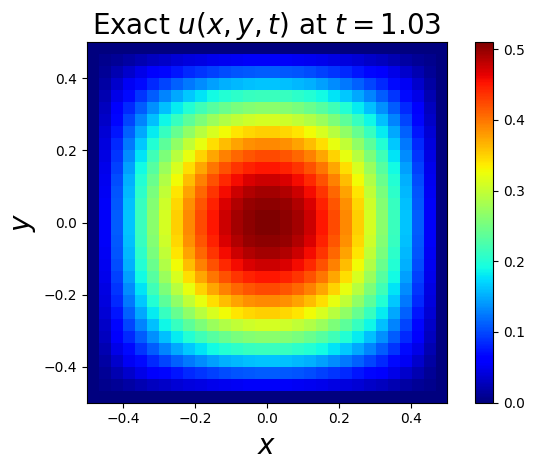

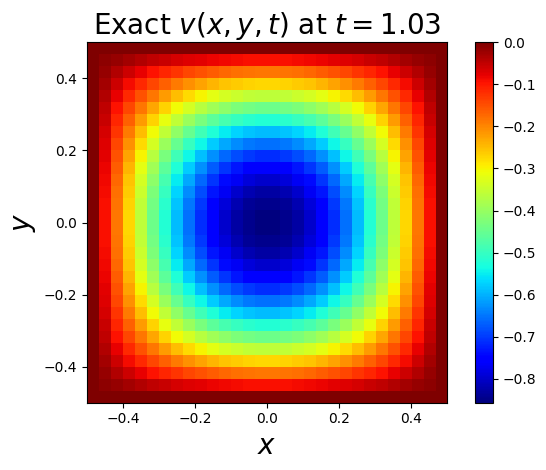

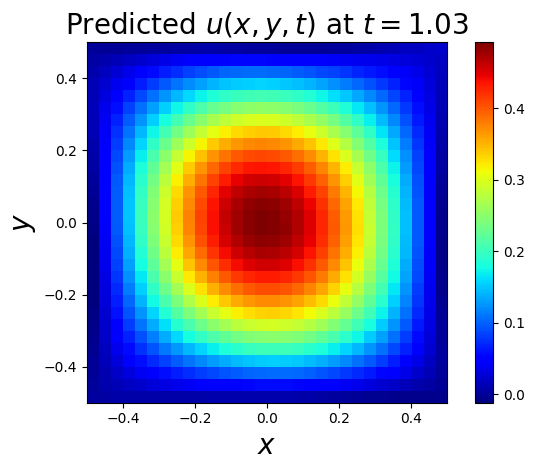

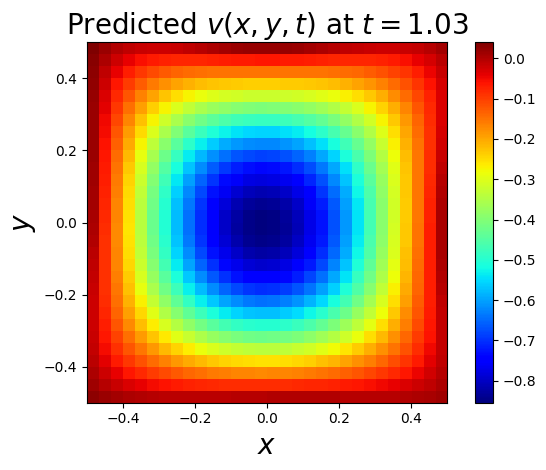

In [4]:
def draw_exact():
    predict_np = model.predict_U(x_test).cpu().detach().numpy()
    u_test_np = x_test_exact.cpu().detach().numpy()
    e_u = np.reshape(u_test_np[:, 0], (len(t), len(x), len(y)))
    e_v = np.reshape(u_test_np[:, 1], (len(t), len(x), len(y)))

    pred_u = np.reshape(predict_np[:, 0], (len(t), len(x), len(y)))
    pred_v = np.reshape(predict_np[:, 1], (len(t), len(x), len(y)))

    time_idx = 6  # t=1
    plt.figure()
    plt.imshow(e_u[time_idx, :, :], extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    
    plt.ylabel('$y$', fontsize=20)
    plt.title(r'Exact $u(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('NLSGE_u_exact.jpg')
    plt.show()

    plt.figure()
    plt.imshow(e_v[time_idx, :, :], extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title(r'Exact $v(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('NLSGE_v_exact.jpg')
    plt.show()

    # Predicted solutions
    plt.figure()
    plt.imshow(pred_u[time_idx, :, :], extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title(r'Predicted $u(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('NLSGE_u_pred.jpg')
    plt.show()

    plt.figure()
    plt.imshow(pred_v[time_idx, :, :], extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title(r'Predicted $v(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('NLSGE_v_pred.jpg')
    plt.show()
draw_exact()